<a href="https://colab.research.google.com/github/fareed-asif/Student_Performance_Analysis/blob/main/SP24_BAI_031(PFAI_LAB_ASS_3_TASK4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cleaned = pd.read_csv("/content/cleaned_students.csv")
score_cols = ['math score', 'reading score', 'writing score']
print("Cleaned data loaded. Shape:", cleaned.shape)
print(cleaned.head())

Cleaned data loaded. Shape: (1000, 8)
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none        72.0             72           74.0  
1               completed        69.0             90           88.0  
2                    none        90.0             95           93.0  
3                    none        47.0             57           44.0  
4                    none        76.0             78           75.0  


In [2]:
print("=== Scores by GENDER ===")
print(cleaned.groupby('gender')[score_cols].mean().round(2))

=== Scores by GENDER ===
        math score  reading score  writing score
gender                                          
female       64.61          72.43          72.32
male         68.40          65.47          63.36


In [3]:
print("=== Scores by RACE/ETHNICITY ===")
print(cleaned.groupby('race/ethnicity')[score_cols].mean().round(2))

=== Scores by RACE/ETHNICITY ===
                math score  reading score  writing score
race/ethnicity                                          
group A              62.29          64.74          62.75
group B              64.31          67.41          65.67
group C              64.87          69.07          67.98
group D              67.15          70.03          70.15
group E              73.80          73.05          71.43


In [4]:
print("=== Scores by PARENTAL EDUCATION ===")
print(cleaned.groupby('parental level of education')[score_cols].mean().round(2))

=== Scores by PARENTAL EDUCATION ===
                             math score  reading score  writing score
parental level of education                                          
associate's degree                67.63          70.82          69.90
bachelor's degree                 69.58          73.00          73.38
high school                       62.94          64.76          62.52
master's degree                   69.41          75.37          75.68
some college                      67.34          69.49          68.87
some high school                  64.27          67.02          65.18


In [5]:
print("=== Scores by TEST PREPARATION COURSE ===")
print(cleaned.groupby('test preparation course')[score_cols].mean().round(2))

=== Scores by TEST PREPARATION COURSE ===
                         math score  reading score  writing score
test preparation course                                          
completed                     69.76          73.89          74.42
none                          64.49          66.55          64.62


In [6]:
print("=== CORRELATION MATRIX ===")
corr = cleaned[score_cols].corr()
print(corr.round(3))

print("\n=== What this means ===")
for i in range(len(score_cols)):
    for j in range(i+1, len(score_cols)):
        val = corr.iloc[i,j]
        print(f"{score_cols[i]} vs {score_cols[j]}: {val:.3f}")

=== CORRELATION MATRIX ===
               math score  reading score  writing score
math score          1.000          0.788          0.771
reading score       0.788          1.000          0.950
writing score       0.771          0.950          1.000

=== What this means ===
math score vs reading score: 0.788
math score vs writing score: 0.771
reading score vs writing score: 0.950


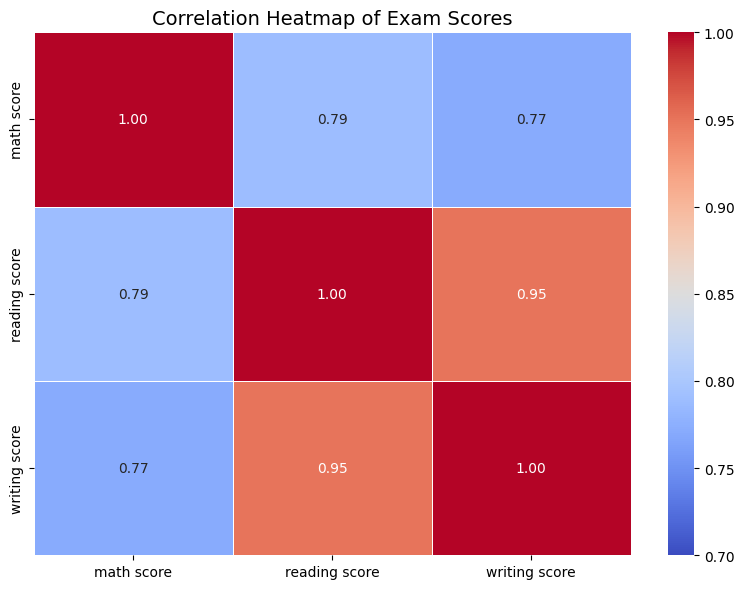

Heatmap saved!


In [7]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    vmin=0.7,
    vmax=1.0
)
plt.title("Correlation Heatmap of Exam Scores", fontsize=14)
plt.tight_layout()
plt.savefig("/content/correlation_heatmap.png", dpi=150)
plt.show()
print("Heatmap saved!")

## EDA Insights

### Correlation Analysis
The correlation matrix reveals strong positive relationships
between all three exam scores. Reading and writing scores show
the highest correlation (0.95), meaning students who perform
well in reading almost always perform well in writing. Math
shows a moderately strong correlation (0.78) with both reading
and writing — suggesting general academic ability matters,
but math requires somewhat different skills.

### Gender Differences
Male students score slightly higher in math (avg ~69) while
female students consistently outperform in reading (avg ~72.6)
and writing (avg ~72.5). This gender gap in verbal skills vs
math is a well-documented pattern in education research.

### Effect of Test Preparation
Students who completed the test preparation course scored
5-10 points higher on average in all three subjects. This
suggests that structured preparation has a meaningful impact.

### Race/Ethnicity
Group E students show the highest average scores across all
subjects, while Group A scores the lowest. The gap is
approximately 10-15 points across groups.

### Parental Education
This shows the clearest trend: students with parents who hold
a master's degree score highest on average, while students
whose parents only completed some high school score the lowest.
This suggests socioeconomic background and home academic
environment play a significant role in student performance.